# LIBRARY

In [1]:
import pickle, gzip
import stumpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_curve, auc
from sktime.classification.shapelet_based import ShapeletTransformClassifier
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from scikitplot.metrics import plot_roc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import pandas as pd
import gzip 
import gzip 
import pickle 
from collections import Counter
import matplotlib.pyplot as plt
import gzip
import pickle
import sys
import numpy as np
import warnings
import pandas as pd
from scipy.stats import levene
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", InterpolationWarning)
warnings.simplefilter("ignore", UserWarning)
from collections import Counter

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


# LOAD DATA

In [2]:
with gzip.open("../1.DATASET/CMI_timeseries_personalized.pkl.gz", "rb") as f:
    CMI_timeseries_personalized = pickle.load(f)

# We run motif discovery on the full dataset (all 4307 time series)
# using the same channels we kept for shapelets
CHANNELS = ["X", "Y", "Z", "enmo", "anglez", "light"]
w = 20  # shapelet min length was 4, motif window — adjust as needed

# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_personalized)}")

Number of time series: 4307


# DATAFRAMES

## Cleaning

In [3]:
df = CMI_timeseries_personalized[0].copy()
df.columns

Index(['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light',
       'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id',
       'sii_binary'],
      dtype='object')

In [4]:
cols_to_drop = ["battery_voltage", "timestamp", "quarter", "relative_date_PCIAT", "non-wear_flag", "weekday"]
data_clean   = [df.drop(columns=cols_to_drop, errors="ignore") for df in CMI_timeseries_personalized]

print(f"Columns remaining: {data_clean[0].columns.tolist()}")
print(f"Total subjects   : {len(data_clean)}")

Columns remaining: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'id', 'sii_binary']
Total subjects   : 4307


## id check

In [5]:
all_labels = [df["sii_binary"].iloc[0] for df in data_clean]
all_ids    = [df["id"].iloc[0]         for df in data_clean]

# Filter missing labels
valid_idx    = [i for i, label in enumerate(all_labels) if not pd.isna(label)]
valid_labels = np.array([all_labels[i] for i in valid_idx])
valid_ids    = np.array([all_ids[i]    for i in valid_idx])

print(f"Total datasets          : {len(data_clean)}")
print(f"Valid (non-null label)  : {len(valid_idx)}")
print(f"Unique subject IDs      : {len(set(valid_ids))}")

Total datasets          : 4307
Valid (non-null label)  : 4307
Unique subject IDs      : 372


## split 

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_pos, test_pos = next(gss.split(
    X=valid_idx,
    y=valid_labels,
    groups=valid_ids
))

train_idx = [valid_idx[i] for i in train_pos]
test_idx  = [valid_idx[i] for i in test_pos]

train_dfs = [data_clean[i] for i in train_idx]
test_dfs  = [data_clean[i] for i in test_idx]

In [7]:
train_ids = set(df["id"].iloc[0] for df in train_dfs)
test_ids  = set(df["id"].iloc[0] for df in test_dfs)
overlap   = train_ids & test_ids

print(f"\nTrain datasets  : {len(train_dfs)}")
print(f"Test datasets   : {len(test_dfs)}")
print(f"Total           : {len(train_dfs) + len(test_dfs)}")
print(f"Subject ID overlap (must be 0): {len(overlap)}")


Train datasets  : 3298
Test datasets   : 1009
Total           : 4307
Subject ID overlap (must be 0): 0


# NORMALIZATION

In [8]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light"]

In [9]:
def fit_global_scalers(df_list, signals):
    """Fit one RobustScaler per signal using TRAIN data only."""
    global_scalers = {}
    print("Fitting global scalers on train data...")
    for signal in signals:
        all_values = []
        for df in df_list:
            if signal not in df.columns:
                continue
            y = df[signal].values
            if np.std(y) < 0.0001 or np.ptp(y) == 0:
                continue
            all_values.append(y)
        if not all_values:
            continue
        population = np.concatenate(all_values).reshape(-1, 1)
        q25, q75   = np.percentile(population, [25, 75])
        iqr        = q75 - q25
        signal_std = np.std(population)
        if iqr > 1e-4:
            scaler = RobustScaler()
            scaler.fit(population)
            global_scalers[signal] = ("robust", scaler)
            print(f"  {signal:<18} → RobustScaler   (IQR={iqr:.4f})")
        elif signal_std > 1e-6:
            global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
            print(f"  {signal:<18} → Std fallback   (IQR too small)")
        else:
            global_scalers[signal] = ("zero", None)
            print(f"  {signal:<18} → Zeroed")
    return global_scalers


In [10]:
def apply_global_scalers(df_list, global_scalers):
    """Apply pre-fitted scalers to a list of DataFrames."""
    scaled_list = []
    for df in df_list:
        target_df = df.copy()
        for signal, scaler_info in global_scalers.items():
            if signal not in target_df.columns:
                continue
            y    = target_df[signal].values.copy()
            kind = scaler_info[0]
            if kind == "robust":
                _, scaler = scaler_info
                y_scaled  = scaler.transform(y.reshape(-1, 1)).flatten()
            elif kind == "std_fallback":
                _, median, std = scaler_info
                y_scaled  = (y - median) / std
            else:
                y_scaled  = np.zeros_like(y)
            target_df[signal] = y_scaled
        scaled_list.append(target_df)
    return scaled_list


In [11]:
global_scalers = fit_global_scalers(train_dfs, signals)
train_scaled   = apply_global_scalers(train_dfs, global_scalers)
test_scaled    = apply_global_scalers(test_dfs,  global_scalers)

print(f"\nTrain scaled: {len(train_scaled)} | Test scaled: {len(test_scaled)}")

Fitting global scalers on train data...
  X                  → RobustScaler   (IQR=0.8218)
  Y                  → RobustScaler   (IQR=0.4161)
  Z                  → RobustScaler   (IQR=0.4341)
  enmo               → RobustScaler   (IQR=0.0463)
  anglez             → RobustScaler   (IQR=5.6684)
  light              → RobustScaler   (IQR=1.8133)

Train scaled: 3298 | Test scaled: 1009


## split

In [12]:
FEATURE_SIGNALS = ["X", "Y", "Z", "enmo", "anglez", "non-wear_flag", "light", "weekday"]
TARGET_SIGNAL   = "sii_binary"

def build_Xy(df_list, feature_signals, target_signal):
    X_list, y_list = [], []
    for df in df_list:
        target_value = df[target_signal].iloc[0]
        if pd.isna(target_value):
            continue
        row = {s: pd.Series(df[s].values) for s in feature_signals if s in df.columns}
        X_list.append(row)
        y_list.append(int(target_value))
    return pd.DataFrame(X_list), np.array(y_list)

X_train, y_train = build_Xy(train_scaled, FEATURE_SIGNALS, TARGET_SIGNAL)
X_test,  y_test  = build_Xy(test_scaled,  FEATURE_SIGNALS, TARGET_SIGNAL)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train balance: {np.bincount(y_train)}")
print(f"y_test  balance: {np.bincount(y_test)}")

X_train: (3298, 6) | X_test: (1009, 6)
y_train balance: [2163 1135]
y_test  balance: [724 285]


In [13]:
X_train.head(5)


,X,Y,Z,enmo,anglez,light
0,0 -0.362699 1 -0.195768 2 -0.16336...,0 -0.218036 1 -0.115951 2 -0.15345...,0 0.054826 1 -0.339330 2 -0.40403...,0 0.421299 1 0.656166 2 1.81711...,0 0.049226 1 -0.141432 2 -0.16620...,0 0.584971 1 0.561272 2 -0.04337...
1,0 1.062342 1 1.080796 2 -0.15115...,0 -0.835622 1 -0.794911 2 -0.56060...,0 0.738310 1 0.440988 2 1.05351...,0 -0.257748 1 -0.226816 2 -0.43331...,0 0.866432 1 0.707594 2 0.97506...,0 -0.517141 1 -0.513485 2 -0.51159...
2,0 1.016850 1 -0.397527 2 -0.53761...,0 -0.626825 1 -0.385782 2 -0.47837...,0 1.218674 1 -0.197825 2 0.18548...,0 -0.089567 1 -0.473650 2 -0.58601...,0 1.005884 1 -0.077989 2 0.23283...,0 1.512169 1 1.505113 2 1.49385...
3,0 0.466964 1 0.437922 2 0.59067...,0 0.190001 1 0.034845 2 0.35324...,0 2.455939 1 2.564356 2 0.58296...,0 -0.170237 1 -0.349537 2 -0.26587...,0 1.164188 1 1.175671 2 0.87193...,0 -0.646420 1 -0.643919 2 -0.62874...
4,0 0.934290 1 0.087334 2 0.83972...,0 0.709384 1 0.239305 2 -0.13852...,0 0.466473 1 0.285537 2 -0.77871...,0 1.774990 1 0.449841 2 -0.60007...,0 0.715031 1 0.264147 2 -0.24212...,0 0.484554 1 0.484554 2 0.48455...


In [14]:
y_train.shape

(3298,)

In [15]:
# ── VERIFY BEFORE FITTING ─────────────────────────────────────────────────────

# 1. Shape
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)

# 2. Cell type — must be pd.Series
print("Cell type     :", type(X_train.iloc[0, 0]))

# 3. All time series same length — KNN requires this
lengths = [[len(X_train.iloc[i, j]) for j in range(X_train.shape[1])]
           for i in range(min(10, len(X_train)))]
flat    = [l for row in lengths for l in row]
print("Unique lengths:", set(flat))          # must be exactly ONE value

# 4. No NaN inside any series
has_nan = any(X_train.iloc[i, j].isna().any()
              for i in range(len(X_train))
              for j in range(X_train.shape[1]))
print("Any NaN in X  :", has_nan)            # must be False

# 5. Class balance
print("y_train balance:", np.bincount(y_train))
print("y_test  balance:", np.bincount(y_test))

X_train shape : (3298, 6)
X_test shape  : (1009, 6)
Cell type     : <class 'pandas.core.series.Series'>
Unique lengths: {200}
Any NaN in X  : False
y_train balance: [2163 1135]
y_test  balance: [724 285]


## convert df in 3d df

In [16]:
# Drop unwanted channels. they carry no information for shapelets
cols_to_drop = ["weekday", "non-wear_flag"] 

X_train_filtered = X_train
X_test_filtered  = X_test

print(f"Remaining channels: {list(X_train_filtered.columns)}")  # → 6 channels

FEATURE_SIGNALS_FILTERED = list(X_train_filtered.columns)

print(FEATURE_SIGNALS_FILTERED)

# Convert to 3D numpy array
X_train_3d = np.stack([
    np.stack(X_train_filtered.iloc[i].values)
    for i in range(len(X_train_filtered))
])  # → (n_samples, 6, 200)

X_test_3d = np.stack([
    np.stack(X_test_filtered.iloc[i].values)
    for i in range(len(X_test_filtered))
])

print(f"X_train_3d: {X_train_3d.shape}")  # → (3298, 6, 200)
print(f"X_test_3d:  {X_test_3d.shape}")   # → (1009, 6, 200)
print(type(X_train_3d))

Remaining channels: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
X_train_3d: (3298, 6, 200)
X_test_3d:  (1009, 6, 200)
<class 'numpy.ndarray'>


# MOTIF DISCOVERY per sample, per channel

In [17]:
all_scaled = apply_global_scalers(
    data_clean,
    global_scalers
)

res_list = []

for idx, df_subject in enumerate(all_scaled):
    res_dict = {"sample_index": idx}

    for ch in CHANNELS:
        if ch not in df_subject.columns:
            res_dict[f"{ch}_motifs"]   = []
            res_dict[f"{ch}_discords"] = []
            continue

        ts = df_subject[ch].values.astype(float)

        # Skip if too short
        if len(ts) < w * 2:
            res_dict[f"{ch}_motifs"]   = []
            res_dict[f"{ch}_discords"] = []
            continue

        # Matrix profile via stumpy (handles univariate per channel)
        mp = stumpy.stump(ts, m=w)
        mp_values = mp[:, 0].astype(float)  # distances

        # Top-3 motifs: positions of the two smallest distances
        motif_indices = np.argsort(mp_values)[:3].tolist()  # rough top motifs

        # Top-3 discords: positions of the largest distances
        discord_indices = np.argsort(mp_values)[::-1][:3].tolist()

        res_dict[f"{ch}_motifs"]   = motif_indices
        res_dict[f"{ch}_discords"] = discord_indices

    res_list.append(res_dict)
  

results = pd.DataFrame(res_list)

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## save

In [18]:

results.to_csv("../1.DATASET/motifs_discords.csv", index=False)
print(f"Saved motifs_discords.csv — shape: {results.shape}")

Saved motifs_discords.csv — shape: (4307, 13)


## plots motifs per channel

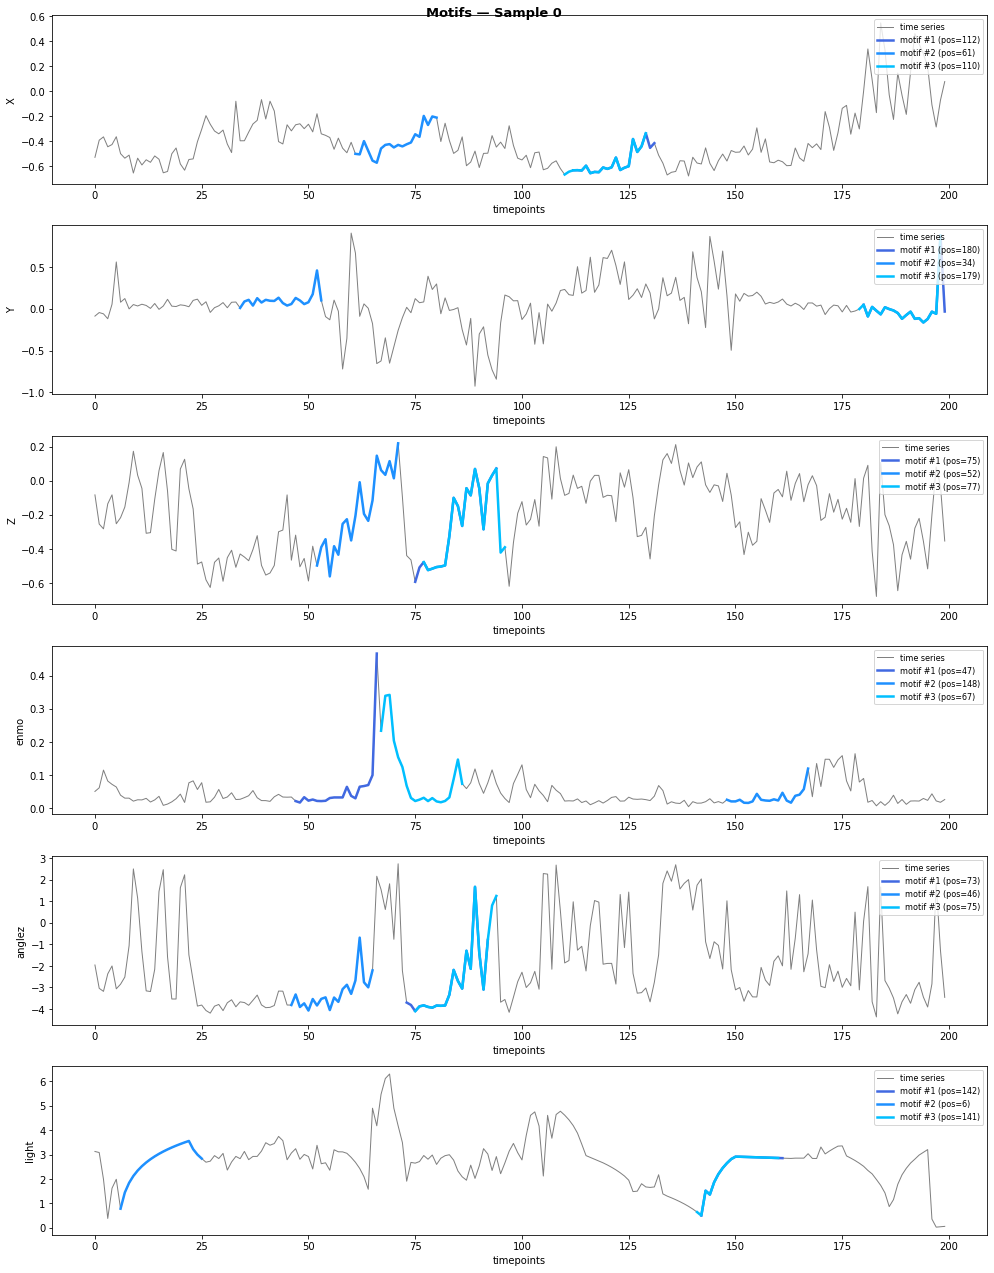

In [19]:
sample_idx = 0
df_subject = CMI_timeseries_personalized[sample_idx]

fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(14, 3 * len(CHANNELS)))
fig.suptitle(f"Motifs — Sample {sample_idx}", fontsize=13, fontweight="bold")

for ax, ch in zip(axes, CHANNELS):
    ts = df_subject[ch].values.astype(float)
    ax.plot(ts, color="gray", lw=1, label="time series")

    motif_pos = results.iloc[sample_idx][f"{ch}_motifs"]
    colors = ["royalblue", "dodgerblue", "deepskyblue",
              "steelblue", "cornflowerblue", "lightblue"]

    for i, pos in enumerate(motif_pos[:6]):
        ax.plot(range(pos, pos + w), ts[pos:pos + w],
                color=colors[i % len(colors)], lw=2.5,
                label=f"motif #{i+1} (pos={pos})")  # ← label added

    ax.set_ylabel(ch)
    ax.set_xlabel("timepoints")
    ax.legend(loc="upper right", fontsize=8)  # ← legend added

plt.tight_layout()
plt.show()

# COMPARISON WITH SHAPELETS

motifs are recurrent, calculated individually for each TS for each signal. shapelets are discriminative patterns, calculated considering the whole dataset

In [20]:
import ast

# ── 1. Load motifs and shapelets ──────────────────────────────────────────────
motifs_discords = pd.read_csv("../1.DATASET/motifs_discords.csv")

# Load shapelets from saved file — no need for rst object
shapelets_raw = np.load('../1.DATASET/shapelets.npy', allow_pickle=True)

shapelets_df = pd.DataFrame(
    shapelets_raw,
    columns=["gain", "length", "start_position", "channel", "index", "class", "shapelet"]
)
shapelets_df["channel_name"] = shapelets_df["channel"].apply(
    lambda c: FEATURE_SIGNALS_FILTERED[int(c)]
)

print(shapelets_df[["gain", "length", "start_position", "channel", "channel_name", "class"]].head(10))

       gain length start_position channel channel_name class
0  0.073542      4             89       5        light     1
1  0.009909     20             50       5        light     0
2  0.009491     13             76       5        light     0
3  0.008739      6             81       5        light     1
4  0.008363      8            175       5        light     0
5  0.008259     14            184       5        light     1
6  0.008119      7            163       5        light     0
7  0.007996     17            118       5        light     0
8  0.007975     11            139       5        light     0
9  0.007883     10            186       5        light     1



Channel 0: X  —  28 shapelets


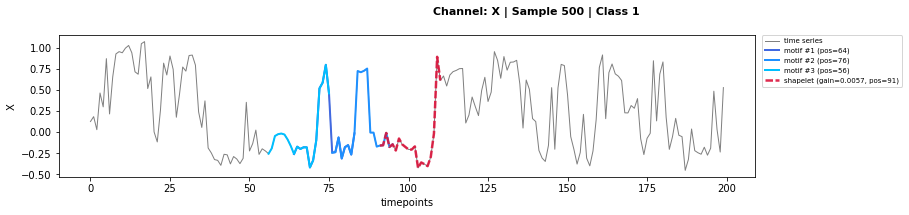


Channel 1: Y  —  13 shapelets


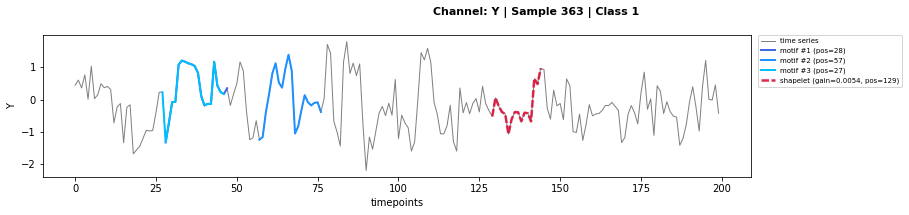


Channel 2: Z  —  13 shapelets


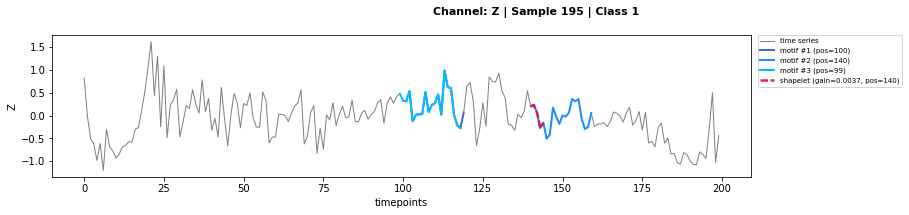


Channel 3: enmo  —  33 shapelets


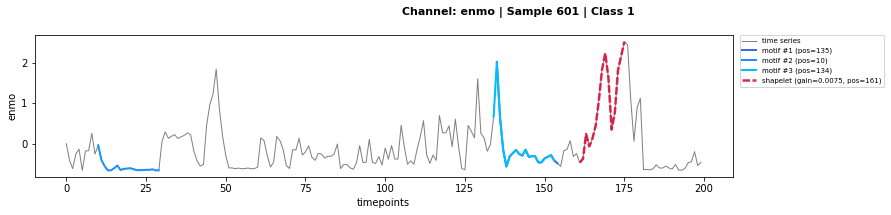


Channel 4: anglez  —  34 shapelets


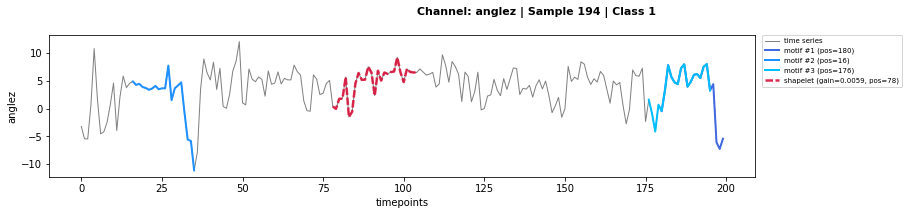


Channel 5: light  —  79 shapelets


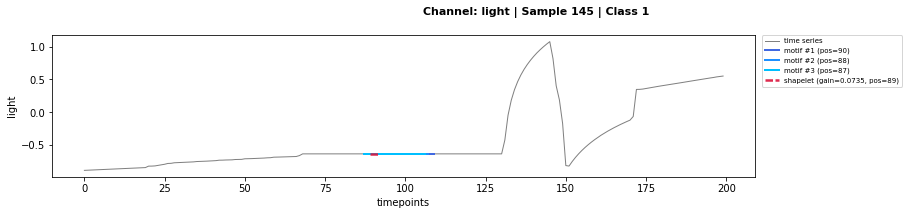

In [21]:
# ── 2. Compare motifs vs shapelets — one plot per channel ─────────────────────
w = 20
for ch_idx, ch_name in enumerate(FEATURE_SIGNALS_FILTERED):
    ch_shapelets = shapelets_df[shapelets_df["channel"] == ch_idx].reset_index(drop=True)
    if len(ch_shapelets) == 0:
        print(f"No shapelets found for channel {ch_idx} ({ch_name}), skipping.")
        continue
    print(f"\n{'='*60}")
    print(f"Channel {ch_idx}: {ch_name}  —  {len(ch_shapelets)} shapelets")
    print(f"{'='*60}")
    best = ch_shapelets.sort_values("gain", ascending=False).iloc[0]
    train_instance_idx = int(best["index"])
    ts = X_train_3d[train_instance_idx, ch_idx, :]
    original_idx = train_idx[train_instance_idx]
    motif_row = motifs_discords.iloc[original_idx]
    try:
        mo    = ast.literal_eval(str(motif_row[f"{ch_name}_motifs"]))
        anoms = ast.literal_eval(str(motif_row[f"{ch_name}_discords"]))
    except Exception:
        mo, anoms = [], []

    fig, ax = plt.subplots(figsize=(15, 3))  
    fig.suptitle(
        f"Channel: {ch_name} | Sample {train_instance_idx} | Class {int(best['class'])}",
        fontsize=11, fontweight="bold"
    )

    # Time series
    ax.plot(ts, color="gray", lw=1, label="time series")

    # Motifs
    motif_colors = ["royalblue", "dodgerblue", "deepskyblue",
                    "steelblue", "cornflowerblue", "lightblue"]
    for i, pos in enumerate(mo[:6]):
        ax.plot(range(pos, pos + w), ts[pos:pos + w],
                color=motif_colors[i % len(motif_colors)],
                lw=2, label=f"motif #{i+1} (pos={pos})")  # ← lw leggermente più spesso

    # Shapelet — tratteggio fine e denso
    s_start = int(best["start_position"])
    s_end   = s_start + int(best["length"])
    ax.plot(
        np.arange(s_start, s_end),
        ts[s_start:s_end],
        lw=2.5, color="crimson", alpha=0.9, zorder=5,
        linestyle=(0, (3, 1)),                          # ← tratteggi fini e ravvicinati
        label=f"shapelet (gain={float(best['gain']):.4f}, pos={s_start})"
    )

    ax.set_xlabel("timepoints")
    ax.set_ylabel(ch_name)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1),   # ← fuori a destra
        borderaxespad=0,
        fontsize=7
    )
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

## overlap ratio

for each channel take all of its the shapelets. retreieve the subject on whick the shapelet was found with its motifs, calculate overlap

In [22]:
def overlap_ratio(s_start, s_end, motif_positions, w):
    """Fraction of shapelet positions covered by at least one motif."""
    shapelet_positions = set(range(s_start, s_end))
    motif_covered = set()
    for pos in motif_positions:
        motif_covered.update(range(pos, pos + w))
    overlap = shapelet_positions & motif_covered
    return len(overlap) / len(shapelet_positions)

In [23]:
for ch_idx, ch_name in enumerate(FEATURE_SIGNALS_FILTERED):

    ch_shapelets = shapelets_df[
        shapelets_df["channel"] == ch_idx
    ].reset_index(drop=True)

    if len(ch_shapelets) == 0:
        continue

    channel_ratios = []

    for _, shp in ch_shapelets.iterrows():

        train_instance_idx = int(shp["index"])

        original_idx = train_idx[train_instance_idx]

        motif_row = motifs_discords.iloc[original_idx]

        try:
            mo = ast.literal_eval(
                str(motif_row[f"{ch_name}_motifs"])
            )
        except Exception:
            mo = []

        s_start = int(shp["start_position"])
        s_end = s_start + int(shp["length"])

        ratio = overlap_ratio(
            s_start,
            s_end,
            mo,
            w
        )

        channel_ratios.append(ratio)

    print(
        f"{ch_name}: "
        f"mean overlap = {np.mean(channel_ratios):.3f}"
    )

X: mean overlap = 0.409
Y: mean overlap = 0.141
Z: mean overlap = 0.466
enmo: mean overlap = 0.204
anglez: mean overlap = 0.365
light: mean overlap = 0.212


partial overlap. some recurrent temporal patterns are also informative for classification